# 06 — MLPAutoencoder Latent Dimension Sweep

Trains one **MLPAutoencoder** per latent dimension `d ∈ {2, 4, 8, 16, 32}` (fixed encoder architecture `n_markers → 256 → 128 → d`) and compares them on:

| Section | Metrics |
|---------|---------|
| 7. Reconstruction loss | Val MSE vs latent dim |
| 8. Embedding quality | ARI · NMI · kNN purity · Silhouette |
| 9. Per-class reconstruction error | Mean MSE per cell type × latent dim (heatmap) |
| 10. Rare-class performance | kNN purity & MSE for minority classes |
| 11. Summary table | All metrics side-by-side |

## 0. Setup

In [10]:
import sys, json, datetime, subprocess, warnings
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm as tqdm_nb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from src.data.loader            import load_processed
from src.data.splits            import load_manifest, apply_splits
from src.models.mlp_autoencoder import MLPAutoencoder
from src.training.trainer       import Trainer, CellUnlabeledDataset, CellVectorDataset
from src.evaluation.metrics     import extract_embeddings_vector, compute_umap
from src.utils.config           import load_config
from src.utils.reproducibility  import set_seed, resolve_device

set_seed(42)
device = resolve_device('mps')
print(f'Device: {device}')

# ── User-editable settings ───────────────────────────────────────────────────
LATENT_DIMS   = [2, 4, 8, 16, 32]   # latent dimensionalities to sweep
HIDDEN_DIMS   = (256, 128)           # encoder hidden layers (fixed across all runs)
MAX_EPOCHS    = 50
PATIENCE      = 10
BATCH_SIZE    = 256
LR            = 3e-4
WEIGHT_DECAY  = 1e-4

# Rare class: bottom RARE_QUANTILE fraction of cell types by count in val_downstream
RARE_QUANTILE = 0.33   # ~bottom third

# Set to a list, e.g. [2, 32], to re-train only those dims.  None = all.
RUN_ONLY_DIMS = None


Device: mps


## 2. Prepare Data (first run only)

In [11]:
DATA_DIR       = PROJECT_ROOT / 'data'
processed_path = DATA_DIR / 'levine32_processed.h5ad'
manifest_path  = DATA_DIR / 'split_manifest.json'

if not processed_path.exists():
    print('Running prepare_data.py …')
    subprocess.run(['python3', str(PROJECT_ROOT / 'scripts' / 'prepare_data.py')],
                   cwd=PROJECT_ROOT, check=True)

if not manifest_path.exists():
    print('Running make_splits.py …')
    subprocess.run(['python3', str(PROJECT_ROOT / 'scripts' / 'make_splits.py')],
                   cwd=PROJECT_ROOT, check=True)

print('Data ready.')


Data ready.


## 3. Load Dataset & Splits

In [12]:
base_cfg  = load_config(str(PROJECT_ROOT / 'configs' / 'base.yaml'))
PREP_CFG  = base_cfg['preprocessing']

print('Loading …')
df        = load_processed(processed_path)
splits    = load_manifest(manifest_path)
split_dfs = apply_splits(df, splits)

print(f'{len(df):,} cells × {len(df.columns)} columns')
for k, v in split_dfs.items():
    print(f'  {k:<25} {len(v):>7,} cells')


Loading …
265,627 cells × 98 columns
  labeled_train              62,510 cells
  labeled_val                20,837 cells
  labeled_test               20,837 cells
  unlabeled_train           145,298 cells
  unlabeled_val              16,145 cells
  train                     207,808 cells
  val_self_supervised        16,145 cells
  val_downstream             20,837 cells
  test                       20,837 cells


## 4. Prepare Data Arrays

In [13]:
# Marker columns (exclude metadata and derived columns)
exclude = {'cell_id', 'label'}
marker_cols = [c for c in df.columns
               if c not in exclude
               and not c.endswith('_rank')
               and not c.endswith('_bin')]
n_markers = len(marker_cols)

# ── Training data (unsupervised — all cells, no labels) ──────────────────────
train_df  = split_dfs['train']           # labeled_train + unlabeled_train
val_ss_df = split_dfs['val_self_supervised']

train_ds  = CellUnlabeledDataset(train_df[marker_cols].values.astype('float32'))
val_ss_ds = CellUnlabeledDataset(val_ss_df[marker_cols].values.astype('float32'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ss_ds, batch_size=BATCH_SIZE, shuffle=False)

# ── Evaluation data (labeled val_downstream — for ARI / kNN / MSE by class) ──
val_down_df      = split_dfs['val_downstream']
val_down_markers = val_down_df[marker_cols].values.astype('float32')
val_down_labels  = val_down_df['label'].values          # string cell-type names

le              = LabelEncoder()
val_down_int    = le.fit_transform(val_down_labels)
label_names     = le.classes_
n_classes       = len(label_names)

# CellVectorDataset — labels only needed for shape; extract_embeddings_vector ignores them
val_down_ds     = CellVectorDataset(val_down_markers, val_down_int)
val_down_loader = DataLoader(val_down_ds, batch_size=512, shuffle=False)

# Class counts (used later for rare-class analysis)
class_counts = pd.Series(val_down_labels).value_counts().sort_values()

print(f'n_markers={n_markers}  n_classes={n_classes}')
print(f'train={len(train_df):,}  val_ss={len(val_ss_df):,}  val_down={len(val_down_df):,}')
print(f'\nClass counts (sorted ascending):')
print(class_counts.to_string())


n_markers=32  n_classes=14
train=207,808  val_ss=16,145  val_down=20,837

Class counts (sorted ascending):
CD34+CD38+CD123+_HSPCs      61
Plasma_B_cells              66
Pro_B_cells                103
CD34+CD38lo_HSCs           183
Basophils                  241
pDCs                       247
CD16+_NK_cells             450
CD34+CD38+CD123-_HSPCs     659
CD16-_NK_cells             781
Pre_B_cells               1227
Mature_B_cells            3304
CD8_T_cells               4022
Monocytes                 4220
CD4_T_cells               5273


## 5. Train — Latent Dimension Sweep

Skips training if a checkpoint already exists for a given dimension.  
Re-run with `RUN_ONLY_DIMS = [d]` to retrain specific dims.

In [ ]:
SWEEP_DIR = PROJECT_ROOT / 'outputs' / 'nb06_latent_sweep'
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

_dims_to_run   = LATENT_DIMS if RUN_ONLY_DIMS is None else [d for d in LATENT_DIMS if d in RUN_ONLY_DIMS]
session_results = {}

for d in tqdm_nb(_dims_to_run, desc='Latent dims', unit='dim'):
    ckpt_dir  = SWEEP_DIR / f'latent_{d:02d}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / 'best_checkpoint.pt'
    summ_path = ckpt_dir / 'training_summary.json'

    if ckpt_path.exists() and summ_path.exists():
        print(f'  d={d:2d}: checkpoint exists — skipping.')
        with open(summ_path) as _f:
            session_results[d] = json.load(_f)
        continue

    print(f'\n▶  d_model={d}  ({n_markers}→256→128→{d}→128→256→{n_markers})')
    model = MLPAutoencoder(n_markers=n_markers, d_model=d, hidden_dims=HIDDEN_DIMS)
    print(f'   params={model.count_parameters():,}')

    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        output_dir=ckpt_dir,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=device,
        mode='reconstruction',
    )
    result = trainer.train()
    result.update({'d_model': d, 'n_params': model.count_parameters()})
    session_results[d] = result

    with open(summ_path, 'w') as _f:
        json.dump(result, _f, indent=2)
    print(f'   ✓  mse={result["best_val_loss"]:.4f}  epoch={result["best_epoch"]}')

print('\n✅ Training complete.')


Latent dims:   0%|          | 0/5 [00:00<?, ?dim/s]


▶  d_model=2  (32→256→128→2→128→256→32)
   params=83,234


Epochs:   0%|                                                                                                 …

   ✓  mse=0.3654  epoch=50

▶  d_model=4  (32→256→128→4→128→256→32)
   params=83,748


Epochs:   0%|                                                                                                 …

   ✓  mse=0.2563  epoch=48

▶  d_model=8  (32→256→128→8→128→256→32)
   params=84,776


Epochs:   0%|                                                                                                 …

## 6. Load Results from Disk

Run this even if training was skipped — it merges session results with any existing checkpoints.

In [14]:
# ── Define sweep directory (also set by train cell, but needed if skipped) ───
SWEEP_DIR = PROJECT_ROOT / 'outputs' / 'nb06_latent_sweep'

# ── Merge session results (if training cell ran) with anything on disk ────────
try:
    _session = session_results          # populated by the training cell
except NameError:
    _session = {}                       # training cell was skipped

sweep_results = {}

for d in LATENT_DIMS:
    if d in _session:
        sweep_results[d] = _session[d]
        continue
    summ_path = SWEEP_DIR / f'latent_{d:02d}' / 'training_summary.json'
    if summ_path.exists():
        with open(summ_path) as _f:
            r = json.load(_f)
        r.setdefault('d_model', d)
        sweep_results[d] = r
        print(f'  Loaded d={d:2d} from disk  mse={r["best_val_loss"]:.4f}  epoch={r["best_epoch"]}')
    else:
        print(f'  ⚠  d={d}: no results found — run the training cell first.')

print(f'\nResults available for dims: {sorted(sweep_results.keys())}')


  Loaded d= 2 from disk  mse=0.3654  epoch=50
  Loaded d= 4 from disk  mse=0.2563  epoch=48
  Loaded d= 8 from disk  mse=0.1511  epoch=50
  Loaded d=16 from disk  mse=0.0609  epoch=48
  Loaded d=32 from disk  mse=0.0166  epoch=50

Results available for dims: [2, 4, 8, 16, 32]


## 7. Evaluate — Embeddings, Metrics & Per-Class Reconstruction Error

For each latent dim:
- Extract **latent embeddings** from `val_downstream` (labeled cells) via `model.encode()`
- Compute **ARI, NMI, kNN purity** (global, using `compute_embedding_metrics`)
- Compute **Silhouette score**
- Compute **per-class kNN purity** (fraction of each cell's 15 nearest neighbours sharing its label)
- Compute **per-cell reconstruction MSE** on `val_downstream`, group by cell type

In [15]:
def perclass_knn_purity(embs, labels_int, label_names, k=15):
    """Return dict {class_name: mean_knn_purity} for each class."""
    nn_model = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', n_jobs=-1)
    nn_model.fit(embs)
    _, indices = nn_model.kneighbors(embs)
    indices = indices[:, 1:]   # exclude self
    per_class = {}
    for cls_idx, cls_name in enumerate(label_names):
        mask = (labels_int == cls_idx)
        if mask.sum() == 0:
            continue
        cls_rows = np.where(mask)[0]
        purities = [(labels_int[indices[i]] == cls_idx).mean() for i in cls_rows]
        per_class[cls_name] = float(np.mean(purities))
    return per_class


eval_results   = {}   # d_model → metrics dict
per_class_mse  = {}   # d_model → pd.Series (class_name → mean MSE)
per_class_knn  = {}   # d_model → dict (class_name → kNN purity)

x_tensor = torch.tensor(val_down_markers, dtype=torch.float32)

for d in tqdm_nb(sorted(sweep_results.keys()), desc='Evaluating', unit='model'):
    ckpt_path = SWEEP_DIR / f'latent_{d:02d}' / 'best_checkpoint.pt'
    if not ckpt_path.exists():
        print(f'  skip d={d}: checkpoint missing')
        continue

    ckpt  = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model = MLPAutoencoder(n_markers=n_markers, d_model=d, hidden_dims=HIDDEN_DIMS)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # ── Latent embeddings ────────────────────────────────────────────────────
    embs = extract_embeddings_vector(model, val_down_loader, device='cpu')  # (N, d)

    # ── Embedding quality ────────────────────────────────────────────────────
    n = len(embs)
    rng = np.random.default_rng(42)

    # ARI & NMI via KMeans + silhouette (subsample if needed)
    from sklearn.cluster import KMeans
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
    km = KMeans(n_clusters=n_classes, random_state=42, n_init='auto')
    pred = km.fit_predict(embs)
    ari = adjusted_rand_score(val_down_int, pred)
    nmi = normalized_mutual_info_score(val_down_int, pred, average_method='arithmetic')

    _idx = rng.choice(n, min(n, 10_000), replace=False)
    sil  = silhouette_score(embs[_idx], val_down_int[_idx], metric='euclidean', random_state=42)

    # kNN purity (global)
    nn_model = NearestNeighbors(n_neighbors=16, metric='euclidean', n_jobs=-1)
    nn_model.fit(embs)
    _, indices = nn_model.kneighbors(embs)
    indices = indices[:, 1:]
    global_knn = float(np.mean([(val_down_int[indices[i]] == val_down_int[i]).mean()
                                 for i in range(n)]))

    # ── Per-class kNN purity ─────────────────────────────────────────────────
    per_class_knn[d] = perclass_knn_purity(embs, val_down_int, label_names, k=15)

    # ── Per-cell reconstruction MSE ──────────────────────────────────────────
    with torch.no_grad():
        recon, _ = model(x_tensor)
    cell_mse = ((recon - x_tensor) ** 2).mean(dim=1).numpy()   # (N,)
    df_mse   = pd.DataFrame({'label': val_down_labels, 'mse': cell_mse})
    per_class_mse[d] = df_mse.groupby('label')['mse'].mean().rename(d)

    eval_results[d] = {
        'embs':       embs,
        'ARI':        ari,
        'NMI':        nmi,
        'knn_purity': global_knn,
        'silhouette': sil,
        'recon_loss': sweep_results[d]['best_val_loss'],
    }
    print(f'  d={d:2d}  ARI={ari:.3f}  NMI={nmi:.3f}  kNN={global_knn:.3f}  '
          f'sil={sil:.3f}  mse={sweep_results[d]["best_val_loss"]:.4f}')

# Combine per-class MSE → DataFrame (cell types × latent dims)
class_mse_df = pd.concat(per_class_mse.values(), axis=1).sort_index()
class_mse_df.columns = sorted(per_class_mse.keys())

# Combine per-class kNN → DataFrame (cell types × latent dims)
class_knn_df = pd.DataFrame(per_class_knn).reindex(sorted(per_class_knn.keys()), axis=1)

print('\nPer-class mean MSE:')
print(class_mse_df.round(4))


Evaluating:   0%|          | 0/5 [00:00<?, ?model/s]

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_95887/3350661001.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_class_mse[d] = df_mse.groupby('label')['mse'].mean().rename(d)


  d= 2  ARI=0.333  NMI=0.574  kNN=0.952  sil=0.255  mse=0.3654


/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_95887/3350661001.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_class_mse[d] = df_mse.groupby('label')['mse'].mean().rename(d)


  d= 4  ARI=0.560  NMI=0.679  kNN=0.955  sil=0.177  mse=0.2563


/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_95887/3350661001.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_class_mse[d] = df_mse.groupby('label')['mse'].mean().rename(d)


  d= 8  ARI=0.547  NMI=0.664  kNN=0.937  sil=0.114  mse=0.1511


/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_95887/3350661001.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_class_mse[d] = df_mse.groupby('label')['mse'].mean().rename(d)


  d=16  ARI=0.577  NMI=0.739  kNN=0.937  sil=0.110  mse=0.0609
  d=32  ARI=0.545  NMI=0.784  kNN=0.962  sil=0.153  mse=0.0166

Per-class mean MSE:
                            2       4       8       16      32
label                                                         
Basophils               0.4097  0.2681  0.1616  0.0662  0.0171
CD4_T_cells             0.2594  0.1858  0.1018  0.0336  0.0092
CD8_T_cells             0.2714  0.1950  0.1103  0.0386  0.0113
CD16+_NK_cells          0.3082  0.2243  0.1343  0.0558  0.0184
CD16-_NK_cells          0.3207  0.2266  0.1312  0.0480  0.0137
CD34+CD38+CD123+_HSPCs  0.5147  0.3106  0.1776  0.0684  0.0193
CD34+CD38+CD123-_HSPCs  0.3687  0.2569  0.1522  0.0610  0.0164
CD34+CD38lo_HSCs        0.3777  0.2492  0.1419  0.0587  0.0153
Mature_B_cells          0.3375  0.2345  0.1355  0.0534  0.0145
Monocytes               0.3685  0.2650  0.1587  0.0649  0.0140
Plasma_B_cells          0.6554  0.3396  0.2250  0.0918  0.0216
Pre_B_cells             0.3086  0.

/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_95887/3350661001.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_class_mse[d] = df_mse.groupby('label')['mse'].mean().rename(d)


## 8. Reconstruction Loss vs Latent Dim

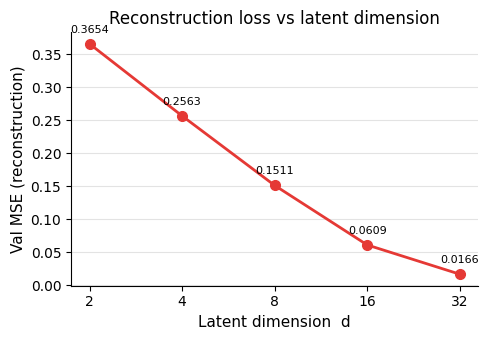

In [16]:
dims  = sorted(eval_results.keys())
mses  = [eval_results[d]['recon_loss'] for d in dims]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(dims, mses, 'o-', color='#E53935', linewidth=2, markersize=7)
for d, v in zip(dims, mses):
    ax.annotate(f'{v:.4f}', (d, v), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

ax.set_xscale('log', base=2)
ax.set_xticks(dims)
ax.set_xticklabels(dims)
ax.set_xlabel('Latent dimension  d', fontsize=11)
ax.set_ylabel('Val MSE (reconstruction)', fontsize=11)
ax.set_title('Reconstruction loss vs latent dimension', fontsize=12)
ax.grid(axis='y', alpha=0.35)
sns.despine()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs' / 'nb06_recon_loss.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Embedding Quality vs Latent Dim

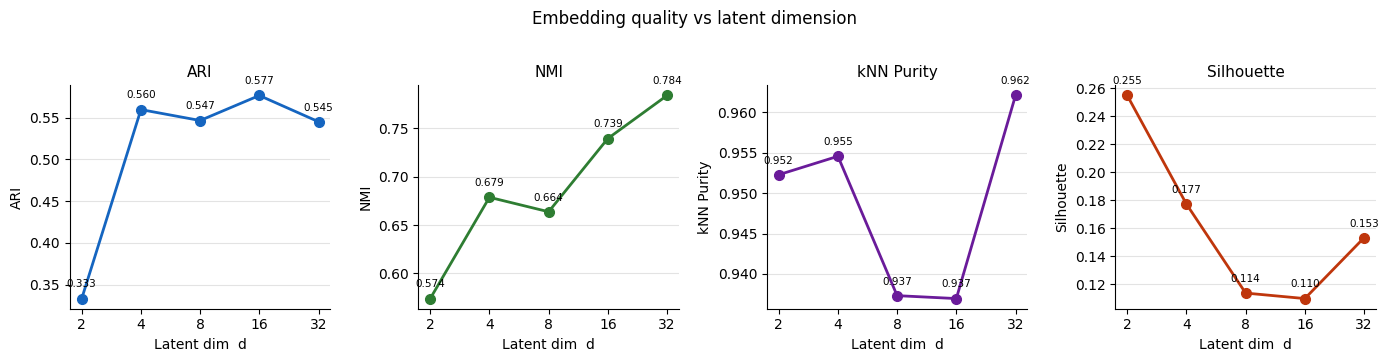

In [17]:
dims    = sorted(eval_results.keys())
metrics = ['ARI', 'NMI', 'knn_purity', 'silhouette']
labels  = ['ARI', 'NMI', 'kNN Purity', 'Silhouette']
colors  = ['#1565C0', '#2E7D32', '#6A1B9A', '#BF360C']

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=False)

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    vals = [eval_results[d][metric] for d in dims]
    ax.plot(dims, vals, 'o-', color=color, linewidth=2, markersize=7)
    for d, v in zip(dims, vals):
        ax.annotate(f'{v:.3f}', (d, v), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7.5)
    ax.set_xscale('log', base=2)
    ax.set_xticks(dims)
    ax.set_xticklabels(dims)
    ax.set_xlabel('Latent dim  d', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.grid(axis='y', alpha=0.35)
    sns.despine(ax=ax)

fig.suptitle('Embedding quality vs latent dimension', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs' / 'nb06_embedding_quality.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Per-Class Reconstruction Error

**Heatmap:** rows = cell types, columns = latent dims.  
Left panel shows raw MSE; right panel shows z-score within each column (reveals which classes are relatively harder regardless of global scale).

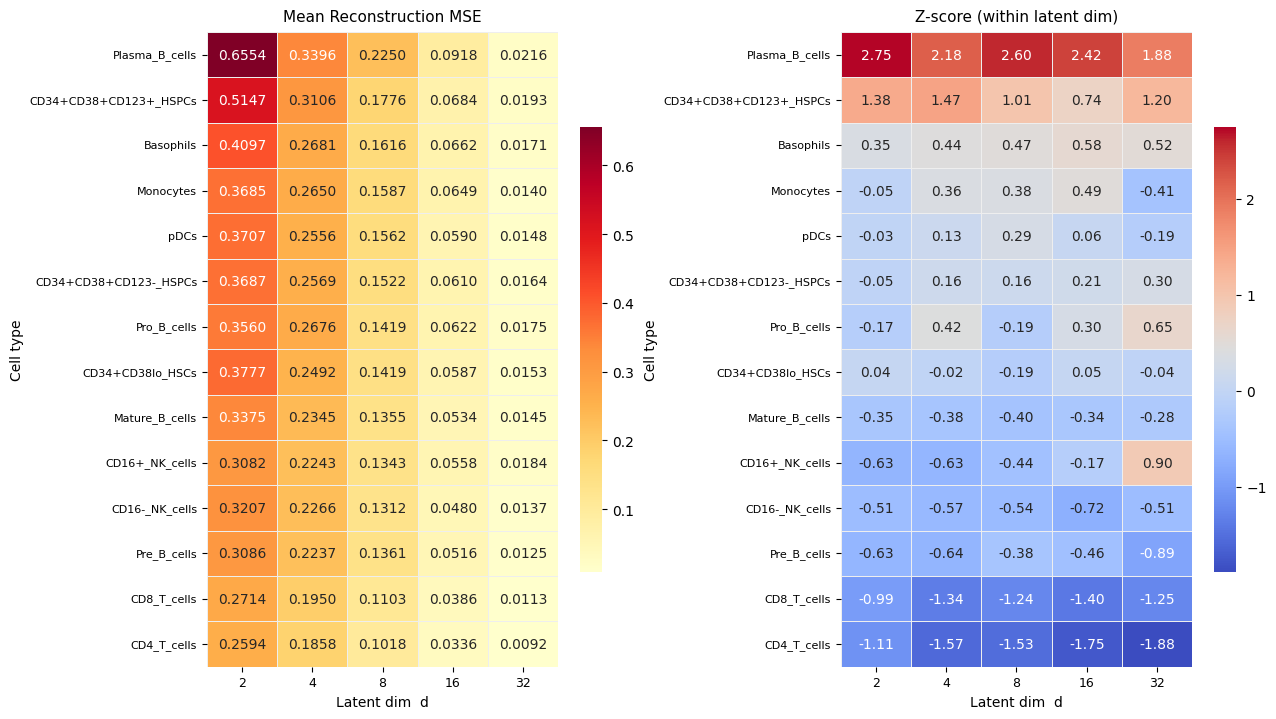

In [18]:
dims = sorted(class_mse_df.columns)
df   = class_mse_df[dims].copy()

# Z-score within each latent dim (column)
df_z = (df - df.mean()) / df.std().replace(0, 1)

# Sort rows by mean MSE (descending — hardest at top)
row_order = df.mean(axis=1).sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(df) * 0.45 + 1)))

for ax, data, title, fmt, cmap in [
    (axes[0], df.loc[row_order],   'Mean Reconstruction MSE',           '.4f', 'YlOrRd'),
    (axes[1], df_z.loc[row_order], 'Z-score (within latent dim)', '.2f', 'coolwarm'),
]:
    sns.heatmap(data, ax=ax, cmap=cmap, annot=True, fmt=fmt,
                linewidths=0.4, linecolor='#eee', cbar_kws={'shrink': 0.7})
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('Latent dim  d', fontsize=10)
    ax.set_ylabel('Cell type', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=9)

fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs' / 'nb06_perclass_mse.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Rare-Class Performance

Identifies the bottom `RARE_QUANTILE` of cell types by count in `val_downstream`.  
Compares **kNN purity** and **reconstruction MSE** for rare vs. common classes across latent dims.  
Shows whether small latent spaces disproportionately hurt minority populations.

Rare threshold  : ≤ 243 cells  (Q33%)
Rare classes    : ['CD34+CD38+CD123+_HSPCs', 'Plasma_B_cells', 'Pro_B_cells', 'CD34+CD38lo_HSCs', 'Basophils']
Common classes  : ['pDCs', 'CD16+_NK_cells', 'CD34+CD38+CD123-_HSPCs', 'CD16-_NK_cells', 'Pre_B_cells', 'Mature_B_cells', 'CD8_T_cells', 'Monocytes', 'CD4_T_cells']



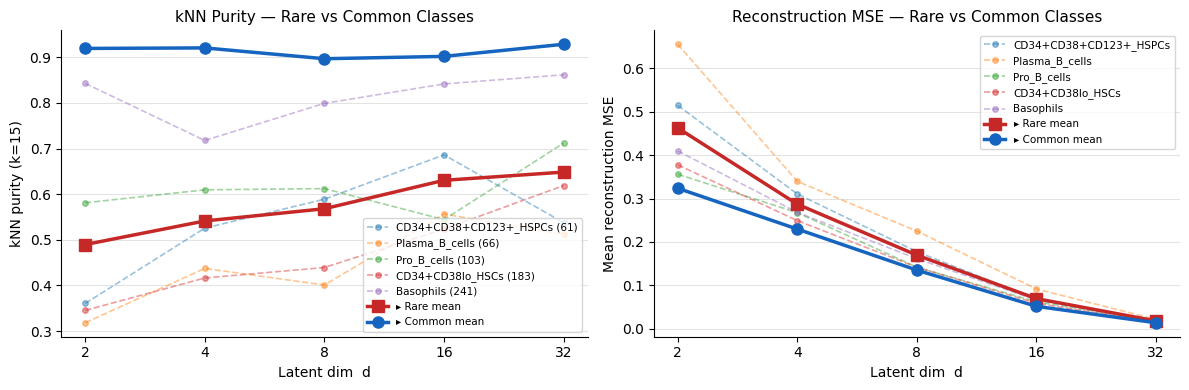

In [19]:
# ── Classify cell types as rare / common ────────────────────────────────────
rare_threshold = class_counts.quantile(RARE_QUANTILE)
rare_classes   = class_counts[class_counts <= rare_threshold].index.tolist()
common_classes = class_counts[class_counts >  rare_threshold].index.tolist()

print(f'Rare threshold  : ≤ {rare_threshold:.0f} cells  (Q{RARE_QUANTILE:.0%})')
print(f'Rare classes    : {rare_classes}')
print(f'Common classes  : {common_classes}')
print()

dims = sorted(class_knn_df.columns)

# ── Build summary DataFrames ─────────────────────────────────────────────────
# Per-dim mean for rare / common
rare_knn_mean   = class_knn_df.loc[rare_classes].mean()
common_knn_mean = class_knn_df.loc[common_classes].mean()

rare_mse_mean   = class_mse_df[dims].loc[rare_classes].mean()
common_mse_mean = class_mse_df[dims].loc[common_classes].mean()

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: kNN purity
ax = axes[0]
# Individual rare class lines (thin, semi-transparent)
for cls in rare_classes:
    vals = [class_knn_df.loc[cls, d] if d in class_knn_df.columns else np.nan for d in dims]
    ax.plot(dims, vals, 'o--', alpha=0.45, linewidth=1.2,
            label=f'{cls} ({class_counts[cls]:,})', markersize=4)
# Summary lines
ax.plot(dims, rare_knn_mean[dims], 's-',  color='#C62828', linewidth=2.5,
        markersize=8, label=f'▸ Rare mean', zorder=5)
ax.plot(dims, common_knn_mean[dims], 'o-', color='#1565C0', linewidth=2.5,
        markersize=8, label=f'▸ Common mean', zorder=5)

ax.set_xscale('log', base=2)
ax.set_xticks(dims); ax.set_xticklabels(dims)
ax.set_xlabel('Latent dim  d', fontsize=10)
ax.set_ylabel('kNN purity (k=15)', fontsize=10)
ax.set_title('kNN Purity — Rare vs Common Classes', fontsize=11)
ax.legend(fontsize=7.5, loc='lower right')
ax.grid(axis='y', alpha=0.35)
sns.despine(ax=ax)

# Right: Reconstruction MSE
ax = axes[1]
for cls in rare_classes:
    vals = class_mse_df.loc[cls, dims] if cls in class_mse_df.index else [np.nan]*len(dims)
    ax.plot(dims, vals, 'o--', alpha=0.45, linewidth=1.2,
            label=f'{cls}', markersize=4)
ax.plot(dims, rare_mse_mean[dims],   's-',  color='#C62828', linewidth=2.5,
        markersize=8, label=f'▸ Rare mean', zorder=5)
ax.plot(dims, common_mse_mean[dims], 'o-', color='#1565C0', linewidth=2.5,
        markersize=8, label=f'▸ Common mean', zorder=5)

ax.set_xscale('log', base=2)
ax.set_xticks(dims); ax.set_xticklabels(dims)
ax.set_xlabel('Latent dim  d', fontsize=10)
ax.set_ylabel('Mean reconstruction MSE', fontsize=10)
ax.set_title('Reconstruction MSE — Rare vs Common Classes', fontsize=11)
ax.legend(fontsize=7.5, loc='upper right')
ax.grid(axis='y', alpha=0.35)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs' / 'nb06_rare_class.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Per-Class kNN Purity Heatmap

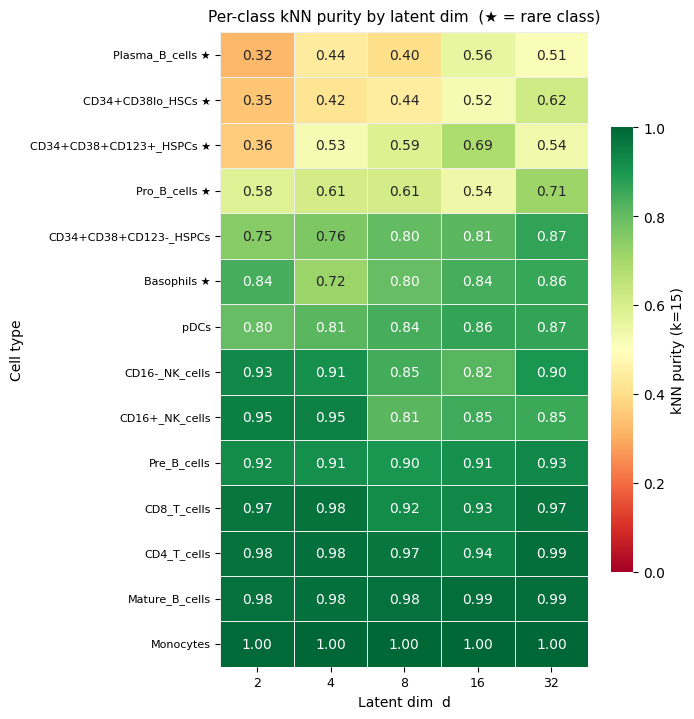

In [20]:
dims = sorted(class_knn_df.columns)
df_knn = class_knn_df[dims].copy()

# Sort rows by mean purity (ascending — hardest at top)
row_order = df_knn.mean(axis=1).sort_values().index

# Annotate rare classes
def row_label(cls):
    tag = ' ★' if cls in rare_classes else ''
    return f'{cls}{tag}'

df_plot = df_knn.loc[row_order].rename(index=row_label)

fig, ax = plt.subplots(figsize=(7, max(4, len(df_plot) * 0.45 + 1)))
sns.heatmap(df_plot, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, linecolor='#eee',
            cbar_kws={'label': 'kNN purity (k=15)', 'shrink': 0.7})
ax.set_title('Per-class kNN purity by latent dim  (★ = rare class)', fontsize=11, pad=8)
ax.set_xlabel('Latent dim  d', fontsize=10)
ax.set_ylabel('Cell type', fontsize=10)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=9)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs' / 'nb06_perclass_knn.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. UMAP Embeddings — Colored by Cell Type

One UMAP per latent dim.  Each point is a cell from `val_downstream`; colour = ground-truth cell type.  ARI and kNN purity are shown in each title so you can see how separation improves with dimensionality.

Computing UMAPs …
  d= 2 done
  d= 4 done
  d= 8 done
  d=16 done
  d=32 done


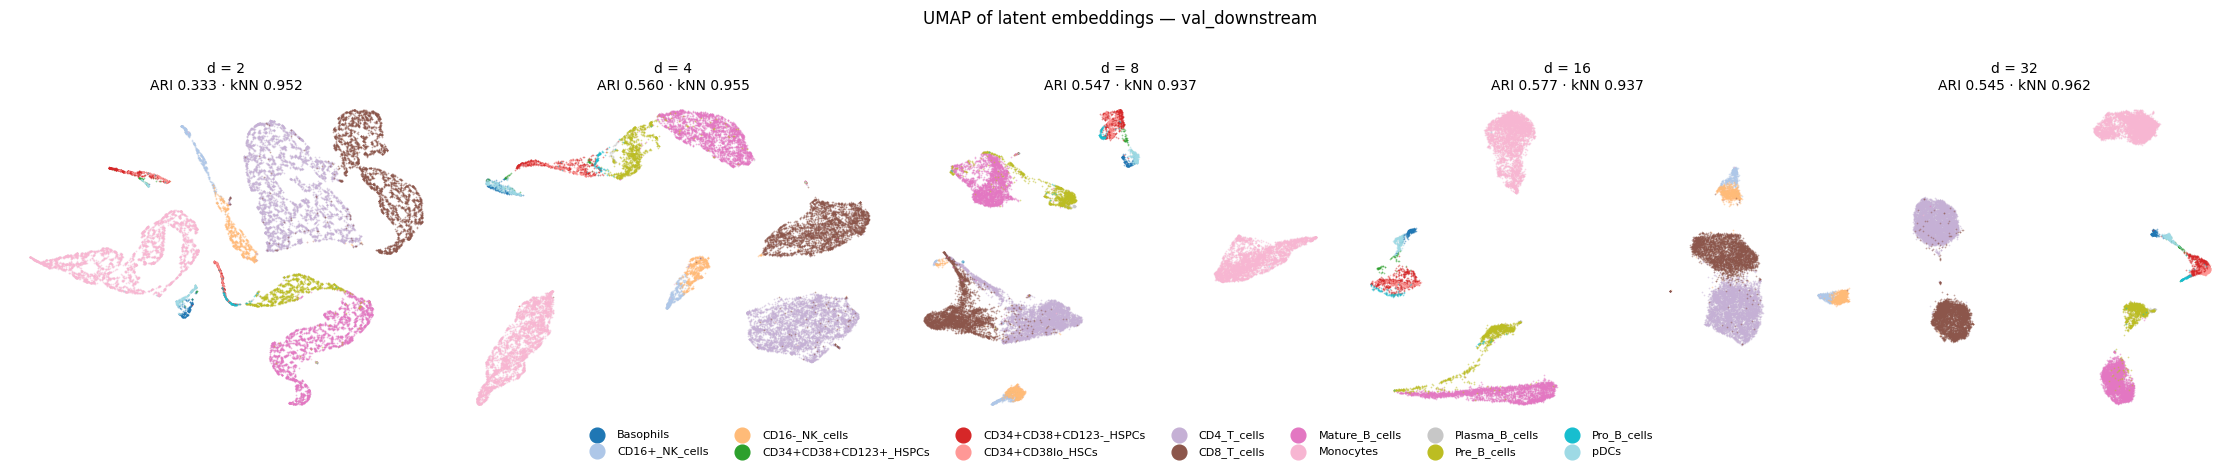

Saved → outputs/nb06_umaps.png


In [21]:
import warnings

dims_to_plot = sorted(eval_results.keys())
n_dims = len(dims_to_plot)

# ── Compute UMAPs (cached in eval_results) ────────────────────────────────────
for d in tqdm_nb(dims_to_plot, desc='Computing UMAPs', unit='dim'):
    if 'umap' not in eval_results[d]:
        embs = eval_results[d]['embs']
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            eval_results[d]['umap'] = compute_umap(embs, n_neighbors=15, min_dist=0.1, seed=42)

# ── Colour palette (one colour per cell type, consistent across panels) ───────
n_types   = len(label_names)
palette   = plt.colormaps['tab20'].resampled(n_types)
color_map = {name: palette(i) for i, name in enumerate(label_names)}

# ── Layout: single row, one panel per dim ─────────────────────────────────────
fig, axes = plt.subplots(1, n_dims, figsize=(4.5 * n_dims, 4.2))
if n_dims == 1:
    axes = [axes]

for ax, d in tqdm_nb(list(zip(axes, dims_to_plot)), desc='Plotting panels', unit='panel'):
    coords = eval_results[d]['umap']
    ari    = eval_results[d]['ARI']
    knn    = eval_results[d]['knn_purity']

    for ct in label_names:
        mask = val_down_labels == ct
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=1.5, alpha=0.5, linewidths=0,
                   color=color_map[ct], label=ct, rasterized=True)

    ax.set_title(f'd = {d}\nARI {ari:.3f} · kNN {knn:.3f}', fontsize=10, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

# ── Shared legend (below the panels) ─────────────────────────────────────────
handles = [plt.scatter([], [], s=18, color=color_map[ct], label=ct)
           for ct in label_names]
fig.legend(handles=handles, loc='lower center',
           ncol=min(n_types, 7), fontsize=8,
           bbox_to_anchor=(0.5, -0.08), frameon=False,
           markerscale=2.5)

fig.suptitle('UMAP of latent embeddings — val_downstream', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'outputs' / 'nb06_umaps.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → outputs/nb06_umaps.png')


## 14. Summary Table

In [14]:
rows = []
for d in sorted(eval_results.keys()):
    r = eval_results[d]
    s = sweep_results[d]
    rows.append({
        'Latent dim d':   d,
        'Params':         f'{s.get("n_params", 0):,}',
        'Best epoch':     s['best_epoch'],
        'Val MSE':        round(r['recon_loss'], 5),
        'ARI':            round(r['ARI'],        4),
        'NMI':            round(r['NMI'],        4),
        'kNN purity':     round(r['knn_purity'], 4),
        'Silhouette':     round(r['silhouette'], 4),
        'Rare kNN mean':  round(float(class_knn_df.loc[rare_classes, d].mean()), 4)
                          if d in class_knn_df.columns else float('nan'),
    })

summary_df = pd.DataFrame(rows).set_index('Latent dim d')
print(summary_df.to_string())

# Save
summary_df.to_csv(PROJECT_ROOT / 'outputs' / 'nb06_summary.csv')
print('\nSaved → outputs/nb06_summary.csv')


              Params  Best epoch  Val MSE     ARI     NMI  kNN purity  Silhouette  Rare kNN mean
Latent dim d                                                                                    
2             83,234          50  0.36540  0.3332  0.5740      0.9523      0.2547         0.4897
4             83,748          48  0.25631  0.5597  0.6786      0.9545      0.1772         0.5414
8             84,776          50  0.15107  0.5466  0.6637      0.9373      0.1136         0.5682
16            86,832          48  0.06091  0.5766  0.7393      0.9370      0.1097         0.6305
32            90,944          50  0.01662  0.5452  0.7838      0.9621      0.1531         0.6485

Saved → outputs/nb06_summary.csv
